In [155]:
from census import Census
import geopandas as gpd
import pandas as pd
import numpy as np
import requests
import time
from pathlib import Path
from us import states
from dotenv import load_dotenv
import os
import folium
import seaborn as sns
import matplotlib.pyplot as plt
from branca.colormap import linear
from IPython.display import IFrame

In [143]:
load_dotenv()
census_api_key = os.getenv("census_api_key")
census = Census(key=census_api_key, year=2020)
WALKSCORE_API_KEY = os.getenv("WALKSCORE_API_KEY")


In [144]:
# Get median rent by census tract
median_rent = "B25064_001E"
STATE_FIPS = ["04", "09", "11", "17", "36", "72"]

county_tract_acs_df = []
for state in STATE_FIPS:
    result = census.acs5.get(
        median_rent,
        geo={"for": "tract:*", "in": f"state:{state}"}
    )
    county_tract_acs_df.append(pd.DataFrame(result))

county_tract_acs_df = pd.concat(county_tract_acs_df, ignore_index=True)

# Construct the GEOID column
county_tract_acs_df["GEOID"] = (
    county_tract_acs_df["state"]
    + county_tract_acs_df["county"]
    + county_tract_acs_df["tract"]
)

# replace the nulls and rename to median rent
county_tract_acs_df["median_rent"] = county_tract_acs_df["B25064_001E"].replace(-666666666.0, np.nan)
county_tract_acs_df = county_tract_acs_df.drop(columns=["B25064_001E"])

county_tract_acs_df = county_tract_acs_df.set_index("GEOID")

county_tract_acs_df

,state,county,tract,median_rent
GEOID,,,,
04013061044,04,013,061044,1625.0
04013061045,04,013,061045,2254.0
04013061046,04,013,061046,891.0
04013061047,04,013,061047,1635.0
04013061048,04,013,061048,1953.0
...,...,...,...,...
72127004600,72,127,004600,603.0
72127004700,72,127,004700,443.0
72127004800,72,127,004800,223.0


In [145]:
# Pull the shapefiles for each census tract 
gdfs = []
for fips in STATE_FIPS:
    url = f"https://www2.census.gov/geo/tiger/TIGER2023/TRACT/tl_2023_{fips}_tract.zip"
    gdfs.append(gpd.read_file(url))

gdf = pd.concat(gdfs, ignore_index=True)
gdf = gdf[['GEOID','geometry']]

# get the centroids
gdf["centroid"] = gdf['geometry'].centroid

# Merge shapefiles into our county_tract_acs_df
gdf = pd.merge(gdf, county_tract_acs_df, on="GEOID", how='inner')


/var/folders/9w/wmrxfcx10_vbgl32_ldgm0140000gn/T/ipykernel_5510/342693017.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["centroid"] = gdf['geometry'].centroid


In [146]:
# Use USDA ruca scores to pull urban rural coding and filter our gdf to only include urban 
ruca = pd.read_csv("RUCA-codes-2020-tract.csv",  encoding="latin-1", dtype={"GEOID": str})
ruca['GEOID'] = ruca['TractFIPS20']
ruca_simple = ruca[['GEOID', 'UrbanCoreType']]
ruca_simple["GEOID"] = ruca_simple["GEOID"].astype(str).str.zfill(11)
gdf = pd.merge(gdf, ruca_simple, on="GEOID", how='inner')

# filter out the rural tracts
gdf = gdf[gdf['UrbanCoreType']=="Metro core"]


In [ ]:
# def get_walk_scores(lat, lon, geoid):
#     params = {
#         "format": "json",
#         "address": geoid,  # using GEOID as a stand-in for address
#         "lat": lat,
#         "lon": lon,
#         "transit": 1,
#         "bike": 1,
#         "wsapikey": WALKSCORE_API_KEY
#     }
#     try:
#         response = requests.get("https://api.walkscore.com/score", params=params, timeout=10)
#         data = response.json()
        
#         if data.get("status") == 1:
#             return {
#                 "GEOID": geoid,
#                 "lat": lat,
#                 "lon": lon,
#                 "walk_score": data.get("walkscore"),
#                 "transit_score": data.get("transit", {}).get("score"),
#                 "bike_score": data.get("bike", {}).get("score"),
#                 "status": 1
#             }
#         else:
#             return {"GEOID": geoid, "lat": lat, "lon": lon, 
#                     "walk_score": None, "transit_score": None, 
#                     "bike_score": None, "status": data.get("status")}
#     except Exception as e:
#         print(f"Error for {geoid}: {e}")
#         return None


# def pull_walk_scores(gdf, daily_limit=5000):
#     if Path("walkscore_results.csv").exists():
#         existing = pd.read_csv("walkscore_results.csv", dtype={"GEOID": str})
#         completed_geoids = set(existing["GEOID"].values)
#         results = existing.to_dict("records")
#         print(f"Resuming — {len(completed_geoids)} already completed")
#     else:
#         completed_geoids = set()
#         results = []

#     remaining = gdf[~gdf["GEOID"].isin(completed_geoids)]
#     to_process = remaining.head(daily_limit)  # cap at daily limit
#     print(f"{len(remaining)} tracts remaining, processing {len(to_process)} today")

#     for i, row in to_process.iterrows():
#         lat = row["centroid"].y
#         lon = row["centroid"].x
#         geoid = row["GEOID"]

#         result = get_walk_scores(lat, lon, geoid)
        
#         if result:
#             results.append(result)

#         if len(results) % 100 == 0:
#             pd.DataFrame(results).to_csv("walkscore_results.csv", index=False)
#             print(f"Saved checkpoint at {len(results)} rows")

#         time.sleep(0.1)

#     pd.DataFrame(results).to_csv("walkscore_results.csv", index=False)
#     print(f"Done for today — {len(results)} total rows saved, {len(remaining) - len(to_process)} remaining")

#     return pd.DataFrame(results)


# scores_df = pull_walk_scores(gdf)

Resuming — 3100 already completed
6196 tracts remaining, processing 5000 today
Saved checkpoint at 3200 rows
Saved checkpoint at 3300 rows
Saved checkpoint at 3400 rows
Saved checkpoint at 3500 rows
Saved checkpoint at 3600 rows
Saved checkpoint at 3700 rows
Saved checkpoint at 3800 rows
Saved checkpoint at 3900 rows
Saved checkpoint at 4000 rows
Error for 17043842300: HTTPSConnectionPool(host='api.walkscore.com', port=443): Read timed out. (read timeout=10)
Saved checkpoint at 4100 rows
Error for 36055011712: HTTPSConnectionPool(host='api.walkscore.com', port=443): Read timed out. (read timeout=10)
Error for 36081112900: HTTPSConnectionPool(host='api.walkscore.com', port=443): Read timed out. (read timeout=10)
Error for 36081029300: HTTPSConnectionPool(host='api.walkscore.com', port=443): Read timed out. (read timeout=10)
Error for 36081028700: HTTPSConnectionPool(host='api.walkscore.com', port=443): Read timed out. (read timeout=10)
Saved checkpoint at 4200 rows
Error for 36081043400

KeyboardInterrupt: 

In [148]:
# merge walkscore results and the gdf
walkscore_results = pd.read_csv("walkscore_results.csv", dtype={"GEOID": str})
walkscore_results_simple = walkscore_results[['GEOID', "walk_score", "transit_score", "bike_score"]]
gdf_with_scores = pd.merge(gdf, walkscore_results_simple, on="GEOID", how='inner')
gdf_with_scores

,GEOID,geometry,centroid,state,county,tract,median_rent,UrbanCoreType,walk_score,transit_score,bike_score
0,04019003003,"POLYGON ((-110.87984 32.24926, -110.87984 32.2...",POINT (-110.8662 32.24716),04,019,003003,808.0,Metro core,52,41.0,72.0
1,04019003707,"POLYGON ((-110.96121 32.15597, -110.96106 32.1...",POINT (-110.95229 32.15183),04,019,003707,796.0,Metro core,11,33.0,43.0
2,04019004067,"POLYGON ((-110.85792 32.2359, -110.85789 32.23...",POINT (-110.84905 32.24057),04,019,004067,1098.0,Metro core,32,42.0,56.0
3,04015952901,"POLYGON ((-114.32511 34.48282, -114.32459 34.4...",POINT (-114.3169 34.47822),04,015,952901,780.0,Metro core,47,NaN,36.0
4,04019003303,"POLYGON ((-110.87547 32.22881, -110.87546 32.2...",POINT (-110.86664 32.22061),04,019,003303,763.0,Metro core,74,38.0,72.0
...,...,...,...,...,...,...,...,...,...,...,...
4895,36085008100,"POLYGON ((-74.10039 40.64312, -74.09957 40.643...",POINT (-74.09377 40.6438),36,085,008100,732.0,Metro core,55,51.0,40.0
4896,36085009601,"POLYGON ((-74.09586 40.59595, -74.0949 40.5963...",POINT (-74.0886 40.59693),36,085,009601,1168.0,Metro core,85,73.0,48.0
4897,36085009602,"POLYGON ((-74.10098 40.59183, -74.10083 40.592...",POINT (-74.09516 40.59078),36,085,009602,1454.0,Metro core,83,69.0,57.0
4898,36061010602,"POLYGON ((-73.96178 40.75988, -73.96173 40.759...",POINT (-73.95804 40.75985),36,061,010602,3142.0,Metro core,93,100.0,83.0


In [149]:
# create an dynamic index for transit mode preference
# each number should add to 100
WALK_IMPORTANCE = .50
BIKE_IMPORTANCE = .40
TRANSIT_IMPORTANCE = .10

def transportation_index(row):
    scores = {}
    weights = {}

    if pd.notna(row["walk_score"]):
        scores["walk"] = row["walk_score"]
        weights["walk"] = WALK_IMPORTANCE
    if pd.notna(row["transit_score"]):
        scores["transit"] = row["transit_score"]
        weights["transit"] = TRANSIT_IMPORTANCE
    if pd.notna(row["bike_score"]):
        scores["bike"] = row["bike_score"]
        weights["bike"] = BIKE_IMPORTANCE

    if not scores:
        return None

    # Renormalize weights to sum to 1
    total_weight = sum(weights.values())
    return sum(scores[k] * weights[k] / total_weight for k in scores)

gdf_with_scores["transportation_index"] = gdf_with_scores.apply(transportation_index, axis=1)
gdf_with_scores

,GEOID,geometry,centroid,state,county,tract,median_rent,UrbanCoreType,walk_score,transit_score,bike_score,transportation_index
0,04019003003,"POLYGON ((-110.87984 32.24926, -110.87984 32.2...",POINT (-110.8662 32.24716),04,019,003003,808.0,Metro core,52,41.0,72.0,58.900000
1,04019003707,"POLYGON ((-110.96121 32.15597, -110.96106 32.1...",POINT (-110.95229 32.15183),04,019,003707,796.0,Metro core,11,33.0,43.0,26.000000
2,04019004067,"POLYGON ((-110.85792 32.2359, -110.85789 32.23...",POINT (-110.84905 32.24057),04,019,004067,1098.0,Metro core,32,42.0,56.0,42.600000
3,04015952901,"POLYGON ((-114.32511 34.48282, -114.32459 34.4...",POINT (-114.3169 34.47822),04,015,952901,780.0,Metro core,47,NaN,36.0,42.111111
4,04019003303,"POLYGON ((-110.87547 32.22881, -110.87546 32.2...",POINT (-110.86664 32.22061),04,019,003303,763.0,Metro core,74,38.0,72.0,69.600000
...,...,...,...,...,...,...,...,...,...,...,...,...
4895,36085008100,"POLYGON ((-74.10039 40.64312, -74.09957 40.643...",POINT (-74.09377 40.6438),36,085,008100,732.0,Metro core,55,51.0,40.0,48.600000
4896,36085009601,"POLYGON ((-74.09586 40.59595, -74.0949 40.5963...",POINT (-74.0886 40.59693),36,085,009601,1168.0,Metro core,85,73.0,48.0,69.000000
4897,36085009602,"POLYGON ((-74.10098 40.59183, -74.10083 40.592...",POINT (-74.09516 40.59078),36,085,009602,1454.0,Metro core,83,69.0,57.0,71.200000
4898,36061010602,"POLYGON ((-73.96178 40.75988, -73.96173 40.759...",POINT (-73.95804 40.75985),36,061,010602,3142.0,Metro core,93,100.0,83.0,89.700000


In [158]:
# Drop rows with no transportation index
all_tracts = gdf_with_scores.dropna(subset=["transportation_index"]).copy()

# Reproject to WGS84 for Folium
all_tracts = all_tracts.to_crs("EPSG:4326")

# Set up colormap
colormap = linear.YlOrRd_09.scale(
    all_tracts["transportation_index"].min(),
    all_tracts["transportation_index"].max()
)
colormap.caption = "Transportation Index"

# Build map centered on US
m = folium.Map(location=[37.8, -96], zoom_start=4, tiles="CartoDB dark_matter")

# Add choropleth layer
folium.GeoJson(
    all_tracts.drop(columns=["centroid"]),
    style_function=lambda feature: {
        "fillColor": colormap(feature["properties"]["transportation_index"]),
        "color": "black",
        "weight": 0.3,
        "fillOpacity": 0.3,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["GEOID", "transportation_index", "walk_score", "transit_score", "bike_score"],
        aliases=["Tract", "Transport Index", "Walk", "Transit", "Bike"],
        localize=True
    )
).add_to(m)

colormap.add_to(m)

m.save("all_tracts_transportation.html")

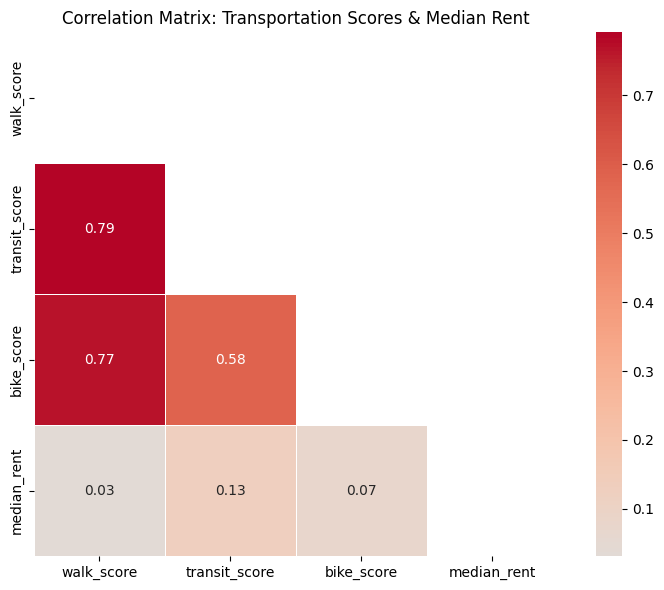

In [157]:
# Select relevant columns
cols = ["walk_score", "transit_score", "bike_score", "median_rent"]
corr = gdf_with_scores[cols].corr()

# Plot
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Correlation Matrix: Transportation Scores & Median Rent")
plt.tight_layout()
plt.show()

In [161]:
from branca.colormap import LinearColormap

MAX_RENT_WTP = 1500  

# Drop rows with no transportation index
all_tracts = gdf_with_scores.dropna(subset=["transportation_index"]).copy()

# Reproject to WGS84 for Folium
all_tracts = all_tracts.to_crs("EPSG:4326")

# Set up beige-to-green colormap
colormap = LinearColormap(
    colors=["#f5f0e8", "#c8d9b0", "#7db87a", "#2d8a4e", "#0a5c2e"],
    vmin=all_tracts["transportation_index"].min(),
    vmax=all_tracts["transportation_index"].max(),
    caption="Transportation Index"
)

# Build map centered on US
m = folium.Map(location=[37.8, -96], zoom_start=4, tiles="CartoDB dark_matter")

def style_function(feature):
    transport_idx = feature["properties"]["transportation_index"]
    median_rent = feature["properties"]["median_rent"]

    # NaN comes through as None in GeoJSON
    if median_rent is None or median_rent != median_rent:  # NaN check
        return {"fillColor": "#000000", "color": "black", "weight": 0.3, "fillOpacity": 0}
    elif median_rent > MAX_RENT_WTP:
        return {"fillColor": "#8B0000", "color": "black", "weight": 0.3, "fillOpacity": 0.7}
    else:
        return {"fillColor": colormap(transport_idx), "color": "black", "weight": 0.3, "fillOpacity": 0.7}

# Add choropleth layer
folium.GeoJson(
    all_tracts.drop(columns=["centroid"]),
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(
        fields=["GEOID", "transportation_index", "walk_score", "transit_score", "bike_score", "median_rent"],
        aliases=["Tract", "Transport Index", "Walk", "Transit", "Bike", "Median Rent"],
        localize=True
    )
).add_to(m)

colormap.add_to(m)

m.save("all_tracts_transportation.html")

from IPython.display import IFrame
IFrame("all_tracts_transportation.html", width=900, height=600)